# From Generation to Acceptance: Predicting, Steering, and Explaining AI-Agent Bug-Fixes

A Q1-oriented deep dive that goes **beyond describing** agentic bug-fix acceptance to **predicting it,
steering it, explaining it, and measuring real autonomy** — on the
[GitHub-Agentic-PR-Dataset](https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset)
(>100-star AIDev-popular population; agents = Claude_Code, Cursor, Copilot, Devin; humans = matched baseline).

**Four contributions (none duplicate the descriptive RQ1a–RQ6):**
- **NC2 — Prediction.** A wasted agent bug-fix is **predictable at submission time** (ROC-AUC ≈ 0.76).
- **NC1 — Intervention.** Adopting an agent-**instruction file does *not* reduce** bug-fix rejection
  (but it does raise test-inclusion and fix size). A hype-tempering, quasi-causal result.
- **NC3 — Autonomy.** ~**81%** of merged *cloud-agent* (Copilot/Devin) fixes need **no human commit**;
  cloud vs local agents differ fundamentally in commit attribution.
- **NC4 — Explanation.** Per-agent acceptance changes over time are **mostly real skill change, not task drift.**

All outcome analyses use a **decision window** (≥60 days to be decided) and a **de-botted** human baseline.

## Data Preparation (Phase 0)

Raw data needs cleaning before modelling — a probe found three problems, all fixed in `analysis_clean.parquet`:

1. **Bots in the "human" baseline.** A naïve `[bot]` filter caught 3.7%, but un-suffixed automation
   (`kibanamachine`, `github-automation-metabase`, `backport-action`, `CBL-Mariner-Bot`, …) pushed the
   real share higher → we remove **21,648 (7.2%)** bot PRs from the human group.
2. **Right-censoring.** Open-share grows to 13.8% by Feb 2026, so outcome analyses keep only **mature**
   PRs (≥60 days old, 83.6%).
3. **Churn artifacts.** 12.7% of changed-file rows are generated/vendored (lockfiles, `.min.js`,
   `vendor/`, …) and per-PR churn maxed at 174M lines → we drop those rows and winsorize at p99.

No duplicates exist; outcome fields are internally consistent. The cleaned table adds `btype` (bug type),
`has_test`, `links_issue`, cleaned `churn`, `n_files`, `n_commits`, de-botted `group`, `mature`, `matched`.

In [ ]:
import os, re, numpy as np, pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
BASE = r"C:\Users\Mahmoudabujadallah\final_agantic_bugfixes"; D = os.path.join(BASE, "data")
clean = pd.read_parquet(os.path.join(BASE, "analysis_clean.parquet"))
print(f"{len(clean):,} fix PRs | agent={int((clean.group=='agent').sum()):,} "
      f"human(clean)={int((clean.group=='human').sum()):,} bots removed={int((clean.group=='bot').sum()):,}")
print(f"mature={100*clean.mature.mean():.1f}% | matched repos cover "
      f"{clean[clean.matched].repo_id.nunique():,} repos")

## NC2 — A wasted agent bug-fix is predictable at submission time

Using only features known when the PR opens (fix size, #files/#commits, has-test, bug type, title/body
length, whether it links an issue, the agent, and the repo's **prior** agent-rejection rate computed
causally), we predict rejection on a **held-out future** period (train < Oct-2025, test Oct–Dec-2025).

**Result: ROC-AUC ≈ 0.76** (PR-AUC 0.50 vs 0.19 base). The dominant signals are **repo strictness**
(its past rejection rate), **which agent** (Devin worst; Claude/Cursor best), **description length**, and
**fix size** — an actionable early-warning triage for likely-wasted agent fixes.

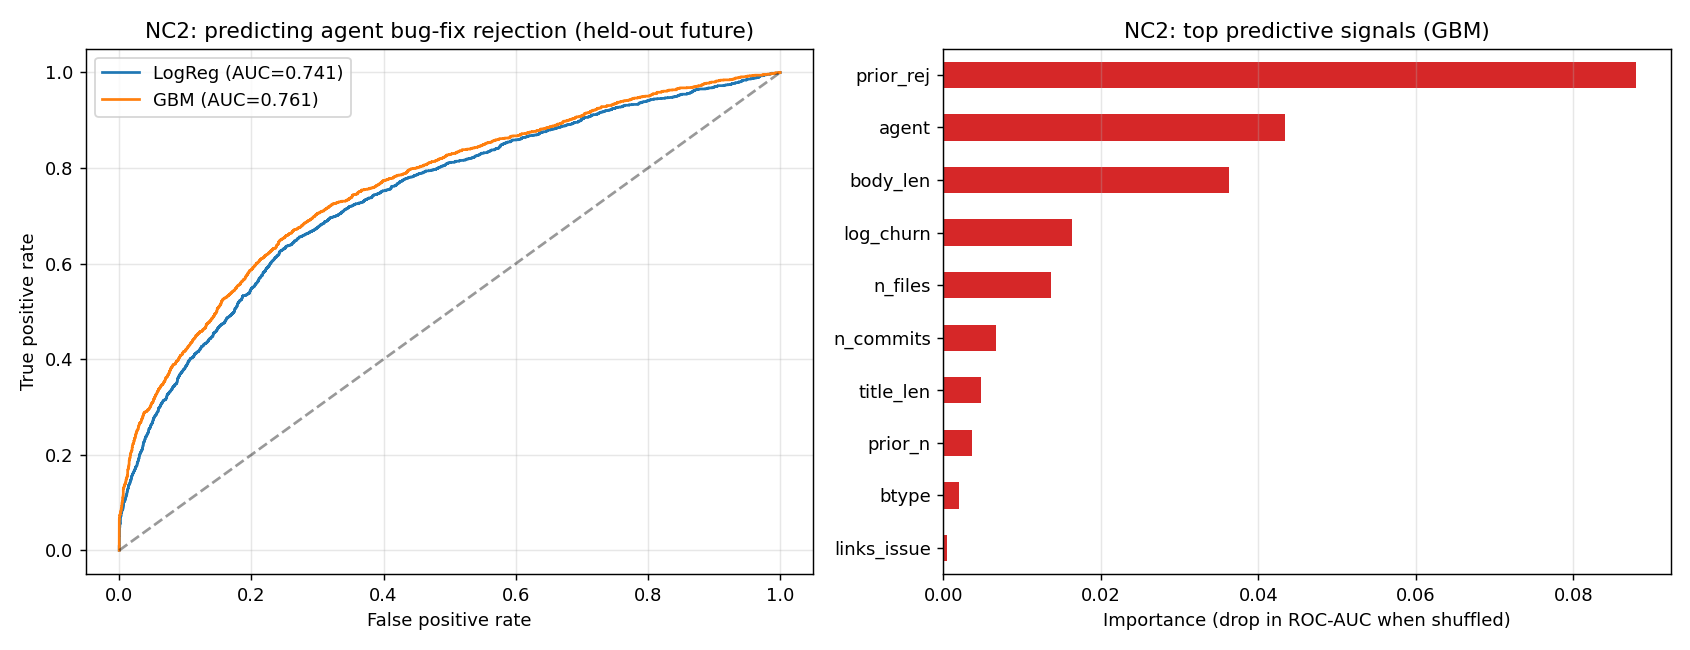

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve
from sklearn.inspection import permutation_importance

d = clean[(clean.group=="agent") & clean.matched & clean.closed].copy().sort_values("created_dt")
d["prior_n"]   = d.groupby("repo_id").cumcount()
d["prior_rej"] = (d.groupby("repo_id")["rejected"].apply(lambda s: s.shift().expanding().mean())
                    .reset_index(level=0, drop=True)).fillna(d["rejected"].mean())
tr = d[d.created_dt < "2025-10-01"]; te = d[(d.created_dt>="2025-10-01") & (d.created_dt<"2026-01-01")]
num=["log_churn","n_files","n_commits","title_len","body_len","prior_rej","prior_n"]; binr=["has_test","links_issue","has_files"]; cat=["agent","btype"]
F=num+binr+cat; ytr,yte=tr.rejected.astype(int),te.rejected.astype(int)
pre=ColumnTransformer([("n",StandardScaler(),num),("b","passthrough",binr),("c",OneHotEncoder(handle_unknown="ignore"),cat)])
gbm=Pipeline([("pre",pre),("clf",HistGradientBoostingClassifier(max_iter=300,learning_rate=0.08))]).fit(tr[F],ytr)
p=gbm.predict_proba(te[F])[:,1]
print(f"GBM ROC-AUC={roc_auc_score(yte,p):.3f}  PR-AUC={average_precision_score(yte,p):.3f}  base={yte.mean():.3f}")
imp=pd.Series(permutation_importance(gbm,te[F],yte,scoring="roc_auc",n_repeats=5,random_state=0).importances_mean,index=F).sort_values()
fig,ax=plt.subplots(1,2,figsize=(13,5))
fpr,tpr,_=roc_curve(yte,p); ax[0].plot(fpr,tpr,label=f"GBM AUC={roc_auc_score(yte,p):.3f}",color="#d62728"); ax[0].plot([0,1],[0,1],"k--",alpha=.4)
ax[0].set_xlabel("FPR"); ax[0].set_ylabel("TPR"); ax[0].set_title("NC2: predicting rejection (held-out future)"); ax[0].legend(); ax[0].grid(alpha=.3)
imp.tail(8).plot.barh(ax=ax[1],color="#d62728"); ax[1].set_title("NC2: top predictive signals"); ax[1].grid(axis="x",alpha=.3)
plt.tight_layout(); plt.show()

## NC1 — Instruction files do *not* reduce bug-fix rejection (they change behaviour, not acceptance)

We date each repo's **adoption** of an agent-instruction file (`CLAUDE.md`, `copilot-instructions.md`,
`AGENTS.md`, `.cursorrules`, …) and run a **difference-in-differences** (repo + month fixed effects) on
agent-fix outcomes: treated repos (adopt, with agent fixes before & after) vs never-adopt controls.

**Result:** adoption has **no significant effect on rejection** (DiD **+1.4 pts**, 95% CI [−1.2, +4.0],
p=0.29; placebo ≈ 0; flat pre-trends → design valid). It **does** significantly raise **test-inclusion
(+6.6 pp)** and **fix size**. So instruction files change *how agents work*, not *whether bug-fixes are
accepted* — tempering a common assumption.

*Limitation:* adoption is dated from instruction-file edits **inside fix PRs** (a lower bound); the
all-PR dating needs an authenticated scan of the 78 GB patch table (HTTP 429 unauthenticated).

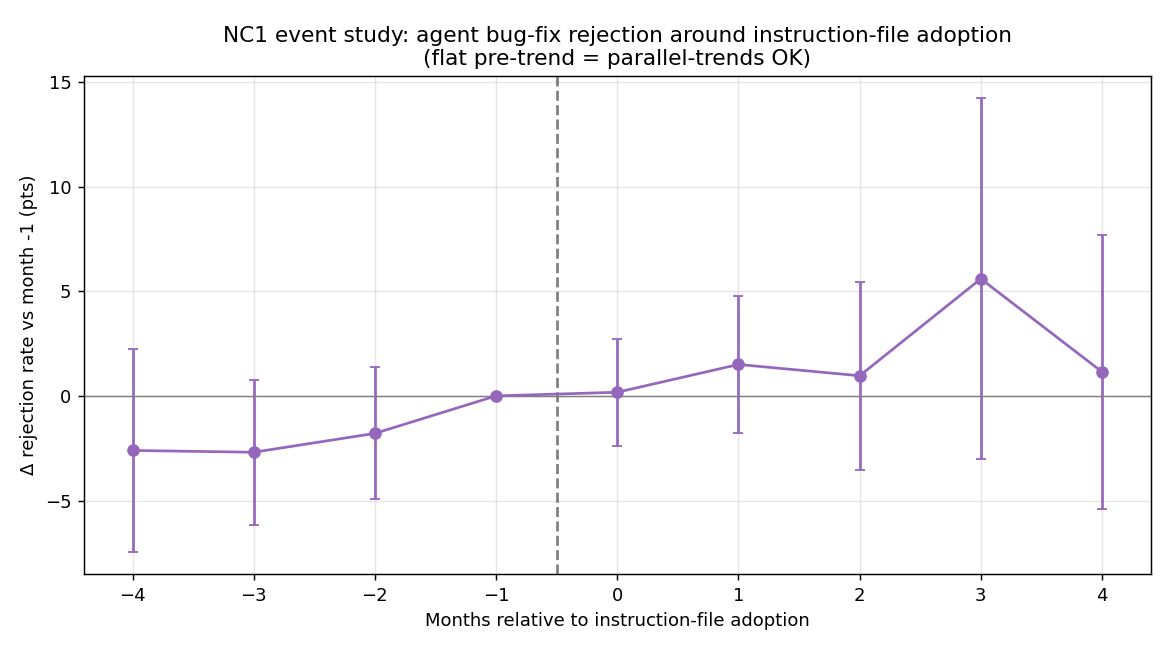

In [ ]:
import statsmodels.formula.api as smf
ad = pd.read_parquet(os.path.join(D,"repo_adoption.parquet"))
midx=lambda s: pd.PeriodIndex(s,freq="M").astype("int64")
g=clean[(clean.group=="agent") & clean.closed & clean.mature].copy(); g["mi"]=midx(g.month); g["rej"]=g.rejected.astype(int)
ad["ai"]=midx(ad.adopt_month); g=g.merge(ad[["repo_id","ai"]],on="repo_id",how="left")
ok=g.dropna(subset=["ai"]).groupby("repo_id").apply(lambda x:(x.mi<x.ai.iloc[0]).any() and (x.mi>=x.ai.iloc[0]).any())
treated=set(ok[ok].index)
never=g[g.ai.isna()]; pool=never.groupby("repo_id").size(); pool=pool[pool>=8].index
ctrl=set(np.random.default_rng(0).choice(pool,min(500,len(pool)),replace=False))
sub=g[g.repo_id.isin(treated|ctrl)].copy(); sub["post"]=(sub.repo_id.isin(treated) & (sub.mi>=sub.ai)).astype(int)
m=smf.ols("rej ~ post + C(repo_id) + C(mi)",data=sub).fit(cov_type="cluster",cov_kwds={"groups":sub.repo_id})
b,se=m.params["post"],m.bse["post"]
print(f"treated={len(treated)} control={len(ctrl)} | DiD on rejection: {b*100:+.2f} pts (95% CI [{(b-1.96*se)*100:+.2f},{(b+1.96*se)*100:+.2f}], p={m.pvalues['post']:.3f})")
for o in ["log_churn","has_test"]:
    sub["_y"]=sub[o].astype(float)
    mm=smf.ols("_y ~ post + C(repo_id) + C(mi)",data=sub).fit(cov_type="cluster",cov_kwds={"groups":sub.repo_id})
    print(f"  effect on {o}: {mm.params['post']:+.3f} (p={mm.pvalues['post']:.3f})")

## NC3 — Agent autonomy: ~81% of merged cloud-agent fixes need no human commit

For each merged agent fix we count commits authored by a human (not the agent/bot). This is clean for
**cloud agents** (Copilot=`Copilot`, Devin=`devin-…[bot]`) but **not** for **local/IDE agents** (Cursor,
Claude_Code) which commit under the **developer's** git identity — a structural distinction worth stating.

**Result (cloud agents):** **autonomy ≈ 81%** (Copilot 78%, Devin 90%) — i.e. ~1 in 5 merged fixes still
needed a human commit, somewhat more for concurrency/network/security. Local agents can't be measured
this way (their "human" commits are the agent acting as the user).

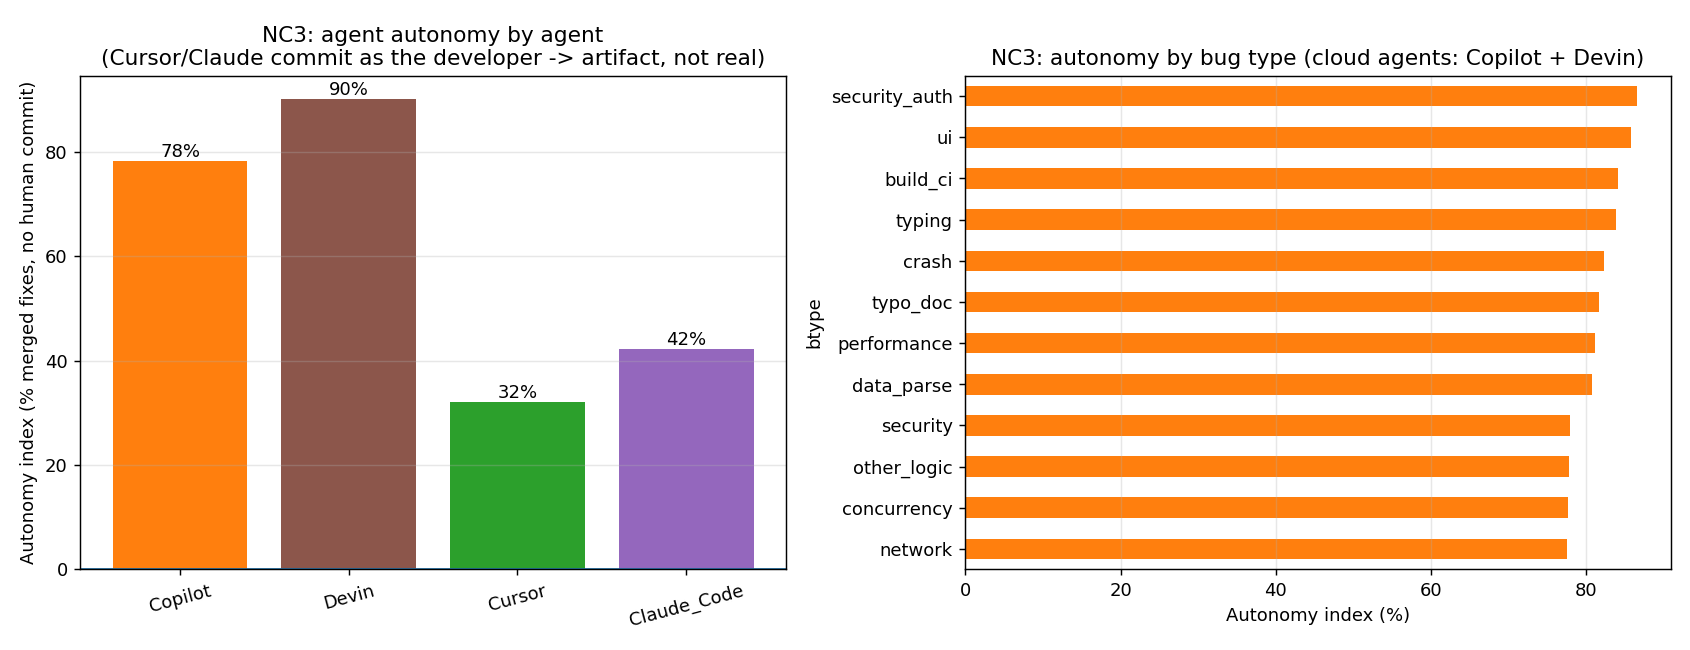

In [ ]:
RELIABLE=["Copilot","Devin"]
ag=clean[(clean.group=="agent") & clean.merged & clean.mature].copy()
c=pd.read_parquet(os.path.join(D,"pr_commits.parquet"),columns=["pr_id","author"]); c=c[c.pr_id.isin(set(ag.id))]
SIG=re.compile(r"copilot|cursoragent|devin|claude|jules|web-flow|\[bot\]|dependabot|renovate|github-actions|actions-user|sweep",re.I)
c["human"]=~c.author.fillna("").map(lambda a: bool(SIG.search(a)) or a=="")
ag=ag.merge(c.groupby("pr_id")["human"].sum().rename("nh"),left_on="id",right_index=True,how="left")
ag["autonomous"]=ag.nh.fillna(0)==0
for a in ["Copilot","Devin","Cursor","Claude_Code"]:
    tag="[cloud]" if a in RELIABLE else "[local: commits as dev -> artifact]"
    print(f"{a:12s} autonomy {100*ag[ag.agent==a].autonomous.mean():5.1f}%  {tag}")
print(f"CLOUD combined: {100*ag[ag.agent.isin(RELIABLE)].autonomous.mean():.1f}%")

## NC4 — Did agents improve, or did tasks get easier/harder? Mostly *real* change

We decompose each agent's early→late change in rejection (Kitagawa–Oaxaca–Blinder) into **composition**
(shift in task mix = bug-type × fix-size) vs **rate** (true change at a fixed task mix).

**Result:** the changes are **mostly genuine "rate" change, not task drift.** Claude_Code improved
(−5.8 pts, ~75% real skill), Copilot/Cursor worsened on the same task mix, Devin improved. Composition
explains only a minority (largest ≈35%, for Claude). So agents really did change — it isn't an artifact
of being handed easier or harder bugs.

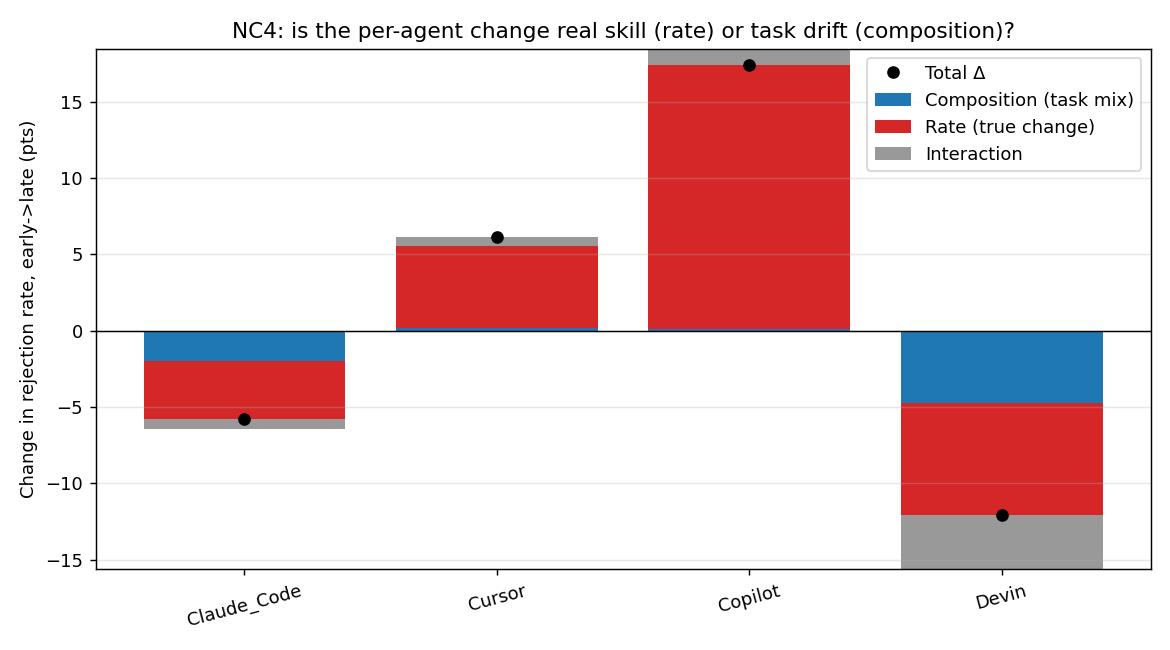

In [ ]:
d=clean[(clean.group=="agent") & clean.closed & clean.mature].copy()
d["cbin"]=pd.cut(d.churn,[-1,10,50,1e12],labels=["s","m","l"]); d["stratum"]=d.btype.astype(str)+"|"+d.cbin.astype(str)
E,L=("2025-01","2025-03"),("2025-10","2025-12")
d=d[d.month.between(*E)|d.month.between(*L)]; d["period"]=np.where(d.month.between(*E),"early","late")
def dec(df):
    e,l=df[df.period=="early"],df[df.period=="late"]
    if len(e)<50 or len(l)<50: return None
    we=(e.groupby("stratum").size()/len(e)); wl=(l.groupby("stratum").size()/len(l))
    re_=e.groupby("stratum").rejected.mean(); rl=l.groupby("stratum").rejected.mean(); S=we.index.union(wl.index)
    we,wl=we.reindex(S,fill_value=0),wl.reindex(S,fill_value=0); re_,rl=re_.reindex(S).fillna(e.rejected.mean()),rl.reindex(S).fillna(l.rejected.mean())
    return dict(delta=(l.rejected.mean()-e.rejected.mean())*100,comp=((wl-we)*re_).sum()*100,rate=(we*(rl-re_)).sum()*100,inter=((wl-we)*(rl-re_)).sum()*100)
for a in ["Claude_Code","Cursor","Copilot","Devin"]:
    r=dec(d[d.agent==a]);
    if r: print(f"{a:12s} Delta={r['delta']:+.1f}  composition={r['comp']:+.1f}  rate(real)={r['rate']:+.1f}  inter={r['inter']:+.1f}")

## Threats to validity

- **Matched within-repo** comparison and **bug-fix-only** scope throughout; **effect sizes + CIs**, not
  bare p-values (n is large).
- **NC1** adoption is a **lower bound** (instruction edits inside fix PRs); event-study pre-trends are flat
  and the placebo is null, but the all-PR dating (78 GB scan) needs an HF token.
- **NC3** autonomy is only measurable for **cloud** agents; local agents commit as the developer.
- **NC2** uses a strict temporal split with a causal (past-only) repo-history feature to avoid leakage.
- Bug types come from a keyword heuristic (validation sample in `review_fix_label_sample.csv`); the
  absolute rejection rate is not comparable to the MSR paper (fix-set definition) — claims are relative.

## Bottom line
Agentic bug-fix acceptance is **predictable** (NC2) and **explainable** (NC4 — real change, not drift),
agents are **largely autonomous when cloud-hosted** (NC3), but the popular lever of **instruction files
does not, by itself, buy higher acceptance** for bug-fixes (NC1) — it changes behaviour (more tests,
bigger diffs). Useful, somewhat contrarian guidance for teams adopting AI bug-fixing agents.